# K-Means Clustering: Theory & Overview

**K-Means** is a widely-used unsupervised learning algorithm for clustering. It partitions a dataset into **K distinct, non-overlapping clusters** based on feature similarity.

---

## ⚙️ How K-Means Works

1. **Initialize**: Choose the number of clusters `K` and initialize `K` centroids (randomly or using K-Means++).
2. **Assignment Step**: Assign each data point to the nearest centroid.
3. **Update Step**: Recalculate each centroid as the mean of the points assigned to it.
4. **Repeat**: Continue steps 2 and 3 until centroids no longer change significantly or a maximum number of iterations is reached.

---

## 🎯 Objective Function

K-Means minimizes the **Within-Cluster Sum of Squares (WCSS)**:

WCSS = Σᵢ Σₓ ∈ Cᵢ ‖x - μᵢ‖²


Where:
- `Cᵢ` is the set of points in cluster `i`
- `μᵢ` is the centroid of cluster `i`
- `x` is a data point in cluster `Cᵢ`

---

## 💡 Applications

- Customer Segmentation  
- Image Compression  
- Market Basket Analysis  
- Pattern Recognition

---

## ⚠️ Limitations

- Assumes clusters are spherical and of similar size  
- Sensitive to initial centroid placement  
- Prone to outliers

---


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load dataset

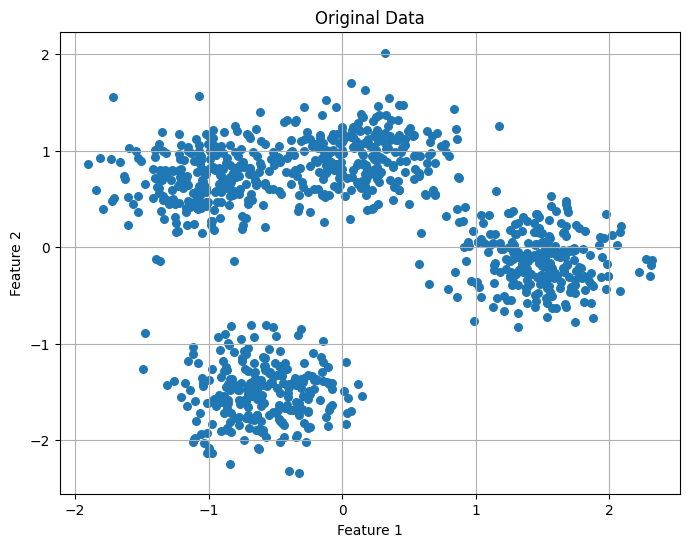

In [16]:
# Generate synthetic dataset
X, y_true = make_blobs(n_samples=1000, centers=4, cluster_std=1.8, random_state=42)


# Standardize data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=30, cmap='viridis')
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

# Determine Optimal K

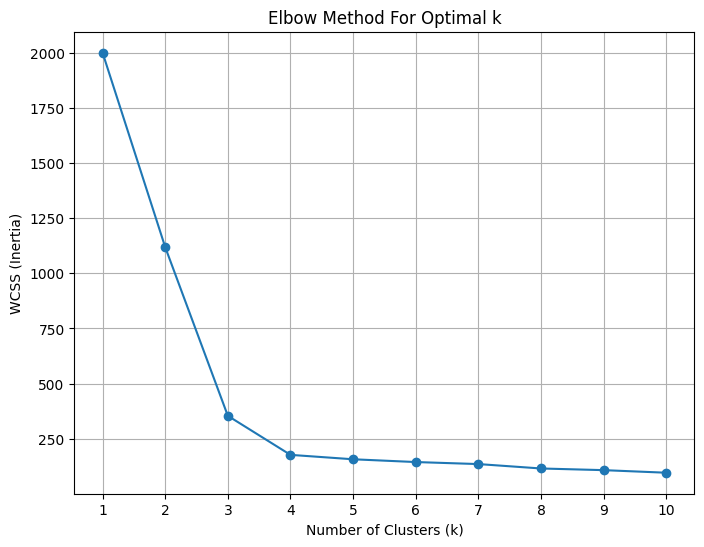

In [17]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # Sum of squared distances to closest cluster center

# Plotting the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Apply K-Means

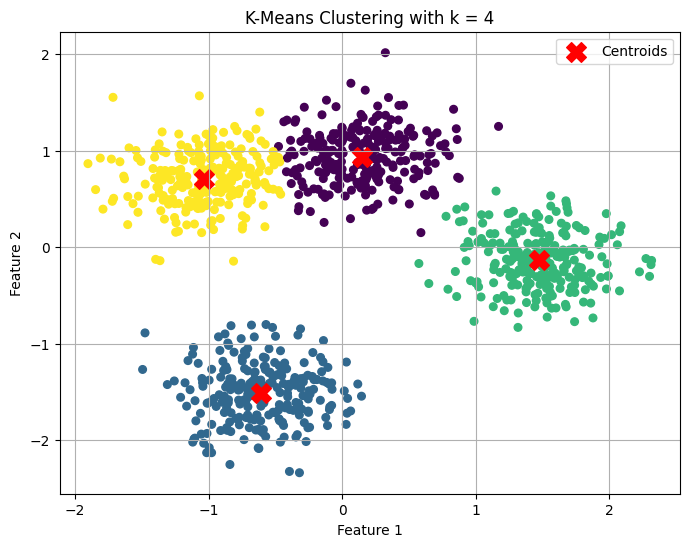

In [18]:
optimal_k = 4  # based on visual inspection of the elbow
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Plot the clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis', s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', s=200, marker='X', label='Centroids')
plt.title(f"K-Means Clustering with k = {optimal_k}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()